# Notebook 3 — Train / Validation / Test Split

**Goal**: split the data before doing any real analysis, so the test set can't
influence any decision made later (feature choices, model choices, etc).

**Reads**: artifacts/labeled_table.parquet (from notebook 2)
**Writes**: artifacts/train.parquet, artifacts/val.parquet, artifacts/test.parquet

In [18]:
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", None)

ARTIFACTS_DIR = Path("artifacts")
df = pd.read_parquet(ARTIFACTS_DIR / "labeled_table.parquet")
df.shape

(96476, 33)

## Random or by time?

This model would run in production on new orders as they come in, always
predicting the future from the past. If we split randomly, the model could end
up training on orders from March and being tested on orders from January,
which is a shape of leakage: it's not seeing raw label values from the future,
but it is being evaluated on a time period it should never have "known about"
relative to training. Splitting by time instead, train on the earliest orders,
test on the most recent ones, matches how it'll actually be used later.

Before deciding for sure, checking two things: the date range we're working
with, and whether the late rate is stable over time or drifting (if the late
rate swings wildly month to month, a time split could hand us a test set
that's not comparable to train just by bad luck).

In [19]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
print("earliest order:", df["order_purchase_timestamp"].min())
print("latest order:  ", df["order_purchase_timestamp"].max())

earliest order: 2016-09-15 12:16:38
latest order:   2018-08-29 15:00:37


In [20]:
monthly = (
    df.set_index("order_purchase_timestamp")
    .resample("MS")["is_late"]
    .mean()
)
monthly

order_purchase_timestamp
2016-09-01    1.000000
2016-10-01    0.011111
2016-11-01         NaN
2016-12-01    0.000000
2017-01-01    0.030667
2017-02-01    0.032063
2017-03-01    0.055774
2017-04-01    0.078593
2017-05-01    0.036107
2017-06-01    0.038596
2017-07-01    0.034349
2017-08-01    0.033150
2017-09-01    0.052048
2017-10-01    0.052925
2017-11-01    0.143112
2017-12-01    0.083802
2018-01-01    0.065639
2018-02-01    0.160006
2018-03-01    0.213623
2018-04-01    0.053104
2018-05-01    0.082383
2018-06-01    0.013615
2018-07-01    0.044834
2018-08-01    0.103921
Freq: MS, Name: is_late, dtype: float64

In [21]:
# late rate alone can be misleading for months with very few orders,
# a single late delivery in a small month swings the rate a lot
monthly_counts = (
    df.set_index("order_purchase_timestamp")
    .resample("MS")["is_late"]
    .count()
)

pd.DataFrame({"n_orders": monthly_counts, "late_rate": monthly}).round(3)

,n_orders,late_rate
order_purchase_timestamp,,
2016-09-01,1,1.000
2016-10-01,270,0.011
2016-11-01,0,NaN
2016-12-01,1,0.000
2017-01-01,750,0.031
2017-02-01,1653,0.032
2017-03-01,2546,0.056
2017-04-01,2303,0.079
2017-05-01,3545,0.036


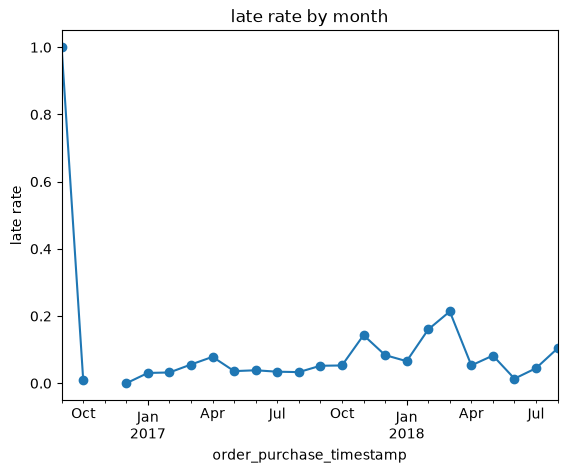

In [22]:
import matplotlib.pyplot as plt

monthly.plot(marker="o")
plt.ylabel("late rate")
plt.title("late rate by month")
plt.show()

2016-09 through 2016-12 have almost no orders (single digits or low tens),
so those extreme rates, 100% in September, NaN in November (zero delivered
orders that month), 0% in December, are just small-sample noise, not a real
signal. From 2017 onward volume is high enough that the rate is meaningful,
and it sits mostly in the 3-8% range with a few real spikes: November 2017
(Black Friday order surge) and February-March 2018 (Olist had known carrier
and logistics disruptions around that period in Brazil). Those spikes are
plausible real events, not noise, so leaving them in rather than treating
them as outliers to remove.

Going with a time-based split. The handful of noisy 2016 months will land in
train regardless of exact cutoff since they're at the very start and there
are so few of them they won't meaningfully affect training.

In [23]:
df_sorted = df.sort_values("order_purchase_timestamp").reset_index(drop=True)

n = len(df_sorted)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = df_sorted.iloc[:train_end]
val = df_sorted.iloc[train_end:val_end]
test = df_sorted.iloc[val_end:]

len(train), len(val), len(test)

(67533, 14471, 14472)

## Checking the split

Two things to confirm: the date ranges shouldn't overlap (train should end
before val starts, val before test starts), and worth looking at the label
balance in each split even though it wasn't forced to match, since a
time-based split can naturally shift it a bit.

In [24]:
for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:5s}  {part['order_purchase_timestamp'].min()}  ->  {part['order_purchase_timestamp'].max()}")

train  2016-09-15 12:16:38  ->  2018-04-15 20:07:56
val    2018-04-15 20:10:23  ->  2018-06-21 07:50:39
test   2018-06-21 08:29:29  ->  2018-08-29 15:00:37


In [25]:
for name, part in [("train", train), ("val", val), ("test", test)]:
    late_rate = part["is_late"].mean() * 100
    print(f"{name:5s}  n={len(part):6d}  late rate={late_rate:.2f}%")

train  n= 67533  late rate=9.03%
val    n= 14471  late rate=5.34%
test   n= 14472  late rate=6.61%


Date ranges don't overlap, which is the main thing. Late rate is fairly close
across the three, so the time split
didn't accidentally hand us a weirdly skewed test set. 

## Saving the artifacts

In [26]:
train.to_parquet(ARTIFACTS_DIR / "train.parquet", index=False)
val.to_parquet(ARTIFACTS_DIR / "val.parquet", index=False)
test.to_parquet(ARTIFACTS_DIR / "test.parquet", index=False)

print("saved train / val / test to artifacts/")

saved train / val / test to artifacts/


Went with a time-based split instead of random, since this model always
predicts forward in production. Checked the late rate wasn't drifting badly
month to month before committing to it, then split 70/15/15 by
order_purchase_timestamp. Confirmed the date ranges don't overlap and the
label balance is close enough across the three splits.